This demo is to show how to extract limb movement timings from raw markerless pose data.

In [1]:
from pathlib import Path

from climbing_analysis.pose.movement_events import extract_movements
from climbing_analysis.pose.io import dask_load_file


import matplotlib.pyplot as plt

First, load and preprocess the pose file. Using `dask_load_file` will provide a pandas dataframe object for a single file. Also print the keys of the dataframe to make sure our node list is accurate.

In [2]:
# create data path
project_root = Path.cwd().parent

# data from https://doi.org/10.1016/j.isci.2026.115901
data_path = project_root / 'examples' / 'sample_data' / 'SKO1-09144_Baseline_20241217_T9.avi.000_SKO1-09144_Baseline_20241217_T9.analysis.h5'

pose_df = dask_load_file(data_path)
print(pose_df.keys())

Index(['r_forepaw_X', 'r_forepaw_Y', 'l_forepaw_X', 'l_forepaw_Y',
       'r_hindpaw_X', 'r_hindpaw_Y', 'l_hindpaw_X', 'l_hindpaw_Y', 'snout_X',
       'snout_Y', 'tail_X', 'tail_Y', 'frame_id', 'Path', 'File', 'Id', 'Type',
       'Date', 'Trial', 'SampleRate'],
      dtype='object')


Create a list for the nodes you want to check movement on. For some nodes, such as snout/tail, this movement extraction may be sub-optimal. This will be used to extract the movements from the pose estimation dataframe

In [3]:
node_list = ['r_forepaw', 'l_forepaw', 'r_hindpaw', 'l_hindpaw']
stance_df = extract_movements(pose_df, node_list = node_list, distance=20)

# examine the dataframe - it should contain start, end, and max arrays for each node along with trial and date information
print(stance_df.head())

                                    r_forepaw  \
start   [4, 54, 150, 310, 491, 625, 799, 963]   
end    [40, 68, 193, 349, 520, 662, 839, 972]   
max    [16, 59, 170, 331, 506, 639, 812, 971]   

                                      l_forepaw  \
start   [92, 203, 280, 407, 555, 709, 898, 910]   
end    [127, 236, 294, 437, 608, 769, 904, 931]   
max    [105, 214, 285, 424, 576, 726, 903, 911]   

                                               r_hindpaw  \
start  [51, 147, 213, 307, 411, 486, 590, 708, 792, 9...   
end    [75, 162, 249, 332, 450, 513, 612, 740, 812, 9...   
max    [61, 152, 233, 320, 440, 493, 599, 720, 798, 9...   

                                               l_hindpaw  trial       date  
start  [84, 163, 195, 261, 343, 403, 488, 555, 625, 7...      9 2024-12-17  
end    [100, 174, 207, 284, 360, 421, 521, 566, 656, ...      9 2024-12-17  
max    [91, 169, 201, 269, 349, 408, 509, 559, 646, 7...      9 2024-12-17  


`stance_df` will contain the indices for the start and end of movements, as well as the maximum velocity across all nodes in the `node_list`. We can check the positions of the movements against the y-coordinates for each node by plotting.

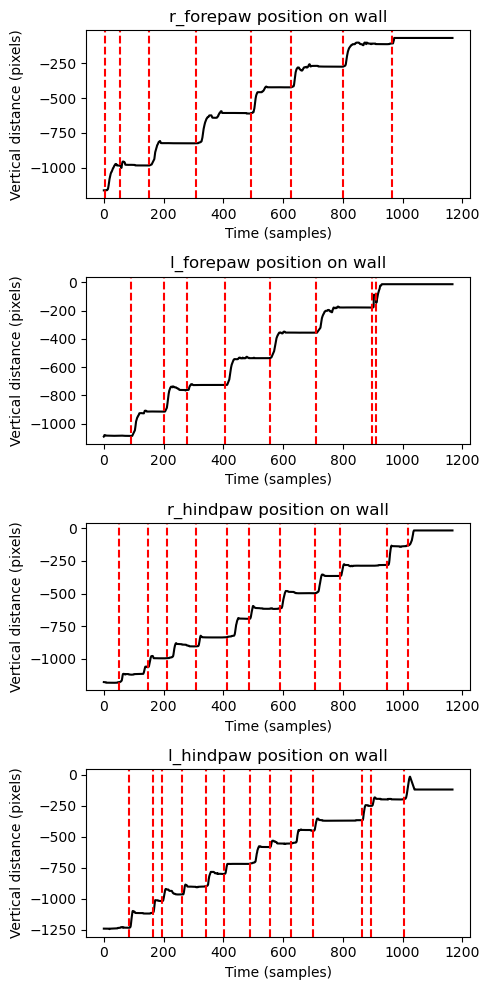

In [ ]:
fig, ax = plt.subplots(nrows=len(node_list), figsize=(5,10))
for i, node in enumerate(node_list):
    ax[i].plot(pose_df[node+'_Y'], color='black')
    for sid in stance_df[node]['start']:
        ax[i].axvline(sid, linestyle='--', color='red')
    ax[i].set_xlabel('Time (samples)')
    ax[i].set_ylabel('Vertical distance (pixels)')
    ax[i].set_title(f'{node} position on wall')

plt.suptitle('Lift off times')
plt.tight_layout()
plt.show()

It's important to keep in mind that the `distance` argument in `extract_movements` should reflect the frequency of expected movements. If the distance value is higher than expected, movement events will go undetected.

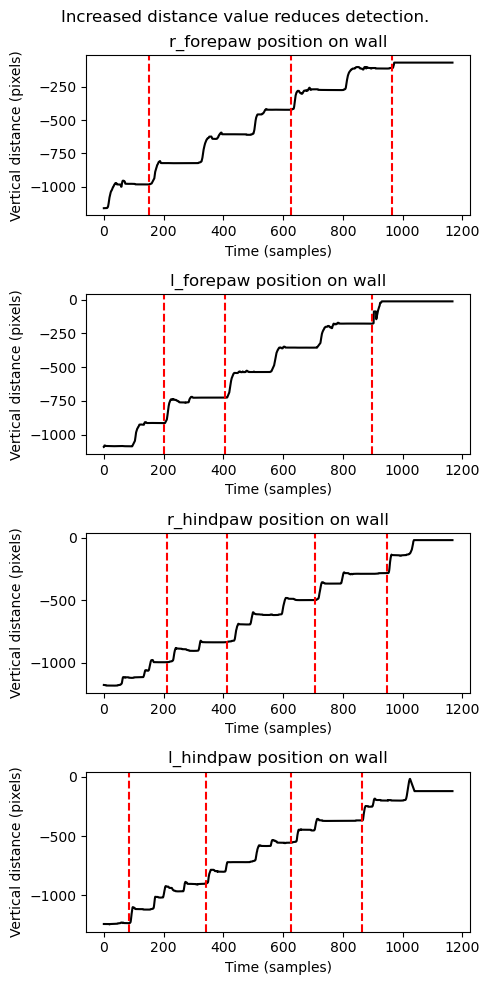

In [ ]:
distance = 200 # from 20
stance_df = extract_movements(pose_df, node_list = node_list, distance=distance)

fig, ax = plt.subplots(nrows=len(node_list), figsize=(5,10))
for i, node in enumerate(node_list):
    ax[i].plot(pose_df[node+'_Y'], color='black')
    for sid in stance_df[node]['start']:
        ax[i].axvline(sid, linestyle='--', color='red')
    ax[i].set_xlabel('Time (samples)')
    ax[i].set_ylabel('Vertical distance (pixels)')
    ax[i].set_title(f'{node} position on wall')

plt.suptitle('Increased distance value reduces detection')
plt.tight_layout()
plt.show()